# Image Compression using Modulo-Compressive Sensing

## Importing Libraries and Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.transform

from optimization.milp import solve_modulo_cs_milp

## Data Exploration

In [2]:
# load csv data to a numpy array
# train_data = np.loadtxt('data/mnist_train.csv', delimiter=',')
test_data = np.loadtxt('data/mnist_test.csv', delimiter=',')

In [3]:
test_data.shape

(10000, 785)

## Generating CS Matrix

In [4]:
def generate_CS_matrix(M:int, N:int):
    # Generate M x N matrix from standard Gaussian
    A = np.random.randn(M, N)

    # Normalize COLUMNS (axis=0) to unit l2 norm
    A = A / np.linalg.norm(A, ord=2, axis=0)

    return A

## Generating Measurements

In [5]:
def generate_measurements(image_data: np.ndarray, num_measurements: int) -> tuple[np.ndarray, np.ndarray]:
    """
        Generate modulo measurements y = [[Ax]], where [[]] denotes the fractional parts of the elements of the vector Ax
        
        Parameters:
            - image_data: np.ndarray flattened vector of the image pixel values
            - num_measurements: int number of samples to be acquired of the 'densified' sparse image

        Returns:
            - np.ndarray: acquired samples y
            - np.ndarray: 2D compressed-sensing matrix    
    """
    
    num_pixels = len(image_data)
    # generating a normalized Gaussian-distributed Compressed Sensing Matrix
    A = generate_CS_matrix(M=num_measurements, N=num_pixels) # M < N
    # acquiring dense modulo samples from the sparse image vector
    y_dense = A @ image_data
    y = y_dense - np.floor(y_dense)

    return y, A

## Sparse Image Recovery

### Rescale image

In [16]:
pixel_width = 14
image_index = 1052 # 91, 2, 1052
# 1. Strip the label (index 0) and grab only the 784 pixels
raw_pixels = test_data[image_index, 1:]

# 2. Reshape to 28x28 and scale to [0, 1]
img_2d = raw_pixels.reshape(28, 28) / 255.0

# 3. Downsample to 14x14 (N=196) to make the MILP problem mathematically feasible
img_small = skimage.transform.resize(img_2d, (pixel_width, pixel_width), anti_aliasing=True)
# Force tiny values to zero to restore sparsity
img_small[img_small < 0.2] = 0.0
raw_image_small = img_small.flatten()
# 4. Flatten back to a 1D vector (length 196)
raw_image_small = img_small.flatten()

### MILP

In [17]:
# Generate measurements using the much smaller, properly processed image
y, A = generate_measurements(image_data=raw_image_small, num_measurements=150)

In [ ]:
# Run the solver (v_bound=10 is safe since the image is scaled [0,1])
x_reconst, integer_part, res = solve_modulo_cs_milp(A, y, v_bound=10, mip_rel_gap=0.8)

# Post-process and plot (remember the reconstructed image is now 14x14)
reconstructed_scaled = np.clip(x_reconst, 0.0, 1.0) * 255.0
img_reconstructed = reconstructed_scaled.reshape(pixel_width, pixel_width)

 Mean Squared Error (MSE): 0.0000


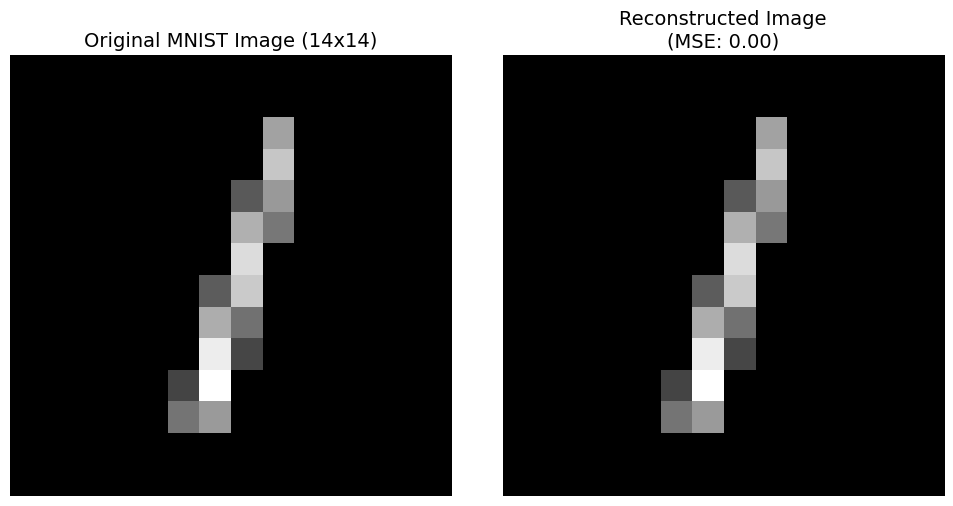

In [15]:
# 3. Define original_scaled to match the 0-255 scale of reconstructed_scaled
original_scaled = raw_image_small * 255.0
mse = np.mean((original_scaled - reconstructed_scaled) ** 2)

print(f"=====================================")
print(f" Mean Squared Error (MSE): {mse:.4f}")
print(f"=====================================")

# 4. Plot the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original Image Plot (Using the 14x14 downsampled image 'img_small')
axes[0].imshow(img_small, cmap='gray')
axes[0].set_title("Original MNIST Image (14x14)", fontsize=14)
axes[0].axis('off')

# Reconstructed Image Plot
axes[1].imshow(img_reconstructed, cmap='gray')
axes[1].set_title(f"Reconstructed Image\n(MSE: {mse:.2f})", fontsize=14)
axes[1].axis('off')

plt.tight_layout()

# plt.savefig("reconstruction14x14_1.png", dpi=300)
plt.show()